## 8.2 - TensorFlow and Keras

In [1]:
import os

import numpy as np

from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras

# Package for loading
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from keras.callbacks import ModelCheckpoint


2025-12-10 06:53:47.276542: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:

base = "clothing-dataset-small/train/t-shirt/"
file = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"    

file_path = os.path.join(base, file)
file_path

'clothing-dataset-small/train/t-shirt/5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'

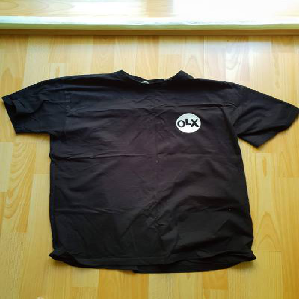

In [4]:
# Specify the size for the neural network
img = load_img(file_path, target_size=(299, 299))
img

In [5]:
# Returs RGB values of the image
x = np.array(img)
x.shape


(299, 299, 3)

## 8.3 - Pre-trained Convolutional Neural Networks

use Xception pretrained model

In [7]:
# 
model = Xception(weights="imagenet", input_shape=(299,299,3))

I0000 00:00:1765255907.062338    7635 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7326 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:0b:00.0, compute capability: 8.6


In [8]:
X = np.array([x])

In [9]:
# Function takes a list of images
model.predict(X)

2025-12-09 06:51:49.196628: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f7f84001ce0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-09 06:51:49.196644: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2025-12-09 06:51:49.222770: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-09 06:51:49.545243: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600
2025-12-09 06:51:52.335348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:51:52.450165: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e

We need to do some pre-processing on the input

In [11]:
X = preprocess_input(X)
X

# Number converted to float in range (-1, 1)

array([[[[ 0.4039216 ,  0.3411765 , -0.2235294 ],
         [ 0.4039216 ,  0.3411765 , -0.2235294 ],
         [ 0.41960788,  0.35686278, -0.20784312],
         ...,
         [ 0.96862745,  0.9843137 ,  0.94509804],
         [ 0.96862745,  0.9843137 ,  0.94509804],
         [ 0.96862745,  0.9843137 ,  0.94509804]],

        [[ 0.47450984,  0.4039216 , -0.1372549 ],
         [ 0.4666667 ,  0.39607847, -0.14509803],
         [ 0.45882356,  0.38823533, -0.15294117],
         ...,
         [ 0.96862745,  0.9764706 ,  0.9372549 ],
         [ 0.96862745,  0.9764706 ,  0.9372549 ],
         [ 0.96862745,  0.9764706 ,  0.92941177]],

        [[ 0.56078434,  0.48235297, -0.00392157],
         [ 0.5686275 ,  0.4901961 ,  0.00392163],
         [ 0.5686275 ,  0.4901961 ,  0.00392163],
         ...,
         [ 0.9607843 ,  0.96862745,  0.92156863],
         [ 0.9607843 ,  0.96862745,  0.92156863],
         [ 0.9607843 ,  0.96862745,  0.92156863]],

        ...,

        [[ 0.2941177 ,  0.18431377, -0

In [12]:
pred = model.predict(X)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


array([[3.23653076e-04, 1.57184579e-04, 2.13852371e-04, 1.52775538e-04,
        2.46388110e-04, 3.03990877e-04, 3.23172397e-04, 1.47127663e-04,
        2.04640892e-04, 1.48533378e-04, 1.95448927e-04, 2.11305698e-04,
        7.60357361e-05, 1.14483410e-04, 1.63856093e-04, 2.06719487e-04,
        1.96100140e-04, 1.44298465e-04, 1.39840457e-04, 1.73443914e-04,
        7.49582134e-04, 2.55245017e-04, 2.66345160e-04, 2.95846112e-04,
        3.71398986e-04, 2.80820153e-04, 2.16456159e-04, 2.26618824e-04,
        3.82413418e-04, 1.71894048e-04, 3.08437971e-04, 1.97605579e-04,
        3.93344992e-04, 4.77847294e-04, 2.90169992e-04, 3.26176727e-04,
        1.46884267e-04, 1.63339500e-04, 2.13810374e-04, 1.34061454e-04,
        2.41512869e-04, 6.71845453e-04, 2.52986763e-04, 1.42742516e-04,
        4.10755951e-04, 2.05432822e-04, 3.03909997e-04, 1.49824453e-04,
        2.00311260e-04, 2.28088087e-04, 2.96851125e-04, 2.30541642e-04,
        6.29143498e-04, 7.80208502e-04, 2.47631775e-04, 4.025621

In [13]:
pred.shape

(1, 1000)

This returns a list of predictions that our image belongs to certain classes

In [15]:
decode_predictions(pred)

[[('n03595614', 'jersey', np.float32(0.67951876)),
  ('n02916936', 'bulletproof_vest', np.float32(0.0395523)),
  ('n04370456', 'sweatshirt', np.float32(0.035304274)),
  ('n03710637', 'maillot', np.float32(0.01088802)),
  ('n04525038', 'velvet', np.float32(0.0018063156))]]

## **8.5 - Transfer Learning**

In [17]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [18]:
dir = "clothing-dataset-small/train"
train_ds = train_gen.flow_from_directory(dir, target_size=(150, 150), batch_size=64)

Found 3068 images belonging to 10 classes.


In [19]:
X, y = next(train_ds)

In [20]:
X.shape

(64, 150, 150, 3)

In [21]:
y[:5]   

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [22]:
y.shape

(64, 10)

In [23]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

dir = "clothing-dataset-small/validation"
val_ds = val_gen.flow_from_directory(
    dir
    , target_size = (150, 150)
    , batch_size = 64
    , shuffle=False
)

Found 341 images belonging to 10 classes.


In [24]:
# Now let's train the model

base_model = Xception(
    weights="imagenet"
    , include_top=False
    , input_shape=(150, 150, 3)
)

base_model.trainable = False

# Create a new "top", or Dense Layers
inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [25]:
preds = model.predict(X)

2025-12-09 06:52:11.365216: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:11.482464: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:12.083662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:12.193639: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:12.808000: E external/local_xla/xla/stream_

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step


In [26]:
preds.shape

(64, 10)

In [27]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)

In [28]:
model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

In [29]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10


2025-12-09 06:52:22.602477: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:22.726572: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:23.428989: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:23.539727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:24.207998: E external/local_xla/xla/stream_

36/48 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.4878 - loss: 1.9853

2025-12-09 06:52:36.634522: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:36.757348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:37.488730: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:37.598859: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:38.276358: E external/local_xla/xla/stream_

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.5265 - loss: 1.8113

2025-12-09 06:52:49.722704: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:49.837209: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:50.360840: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:50.470455: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-09 06:52:50.579686: E external/local_xla/xla/stream_

48/48 ━━━━━━━━━━━━━━━━━━━━ 38s 569ms/step - accuracy: 0.6525 - loss: 1.2322 - val_accuracy: 0.7918 - val_loss: 0.6776
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.8452 - loss: 0.4586 - val_accuracy: 0.8240 - val_loss: 0.5894
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.8866 - loss: 0.3274 - val_accuracy: 0.8152 - val_loss: 0.6928
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.9319 - loss: 0.2069 - val_accuracy: 0.8094 - val_loss: 0.6837
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.9580 - loss: 0.1418 - val_accuracy: 0.8065 - val_loss: 0.7022
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.9684 - loss: 0.1083 - val_accuracy: 0.8182 - val_loss: 0.6873
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.9847 - loss: 0.0775 - val_accuracy: 0.8182 - val_loss: 0.6909
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.9857 - loss: 0.0670 - val_accuracy: 0.8211 - val

In [30]:
history.history["val_accuracy"]

[0.7917888760566711,
 0.8240469098091125,
 0.8152492642402649,
 0.8093841671943665,
 0.8064516186714172,
 0.8181818127632141,
 0.8181818127632141,
 0.8211143612861633,
 0.8211143612861633,
 0.8152492642402649]

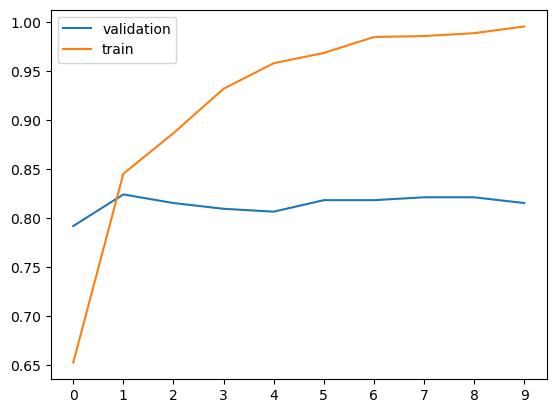

In [ ]:

plt.plot(history.history["val_accuracy"], label="validation")
plt.plot(history.history["accuracy"], label="train")

plt.xticks(np.arange(10))
plt.legend()


## 8.6 - Learning Rate

In [32]:
def make_model(learning_rate=0.01):
    # Now let's train the model

    base_model = Xception(
        weights="imagenet"
        , include_top=False
        , input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    # Create a new "top", or Dense Layers
    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(
        optimizer=optimizer
        , loss=loss
        , metrics=["accuracy"]
    )

    return model

In [33]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]

scores = {}

for lr in tqdm(learning_rates):

    model = make_model(lr)

    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 316ms/step - accuracy: 0.2546 - loss: 2.0968 - val_accuracy: 0.4076 - val_loss: 1.8519
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.4844 - loss: 1.6268 - val_accuracy: 0.5601 - val_loss: 1.5005
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.5792 - loss: 1.3623 - val_accuracy: 0.6158 - val_loss: 1.2856
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.6314 - loss: 1.1944 - val_accuracy: 0.6569 - val_loss: 1.1475
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.6643 - loss: 1.0814 - val_accuracy: 0.6686 - val_loss: 1.0528
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.6838 - loss: 0.9995 - val_accuracy: 0.6950 - val_loss: 0.9826
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.7040 - loss: 0.9358 - val_accuracy: 0.7067 - val_loss: 0.9277
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.7203 - loss: 0.8834 - val_accuracy: 0

 25%|██▌       | 1/4 [01:32<04:37, 92.39s/it]

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 318ms/step - accuracy: 0.5799 - loss: 1.2376 - val_accuracy: 0.7859 - val_loss: 0.7800
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.7656 - loss: 0.7094 - val_accuracy: 0.8182 - val_loss: 0.6559
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.8090 - loss: 0.5731 - val_accuracy: 0.8035 - val_loss: 0.6188
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.8396 - loss: 0.4991 - val_accuracy: 0.8240 - val_loss: 0.5874
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.8628 - loss: 0.4411 - val_accuracy: 0.8152 - val_loss: 0.5746
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.8801 - loss: 0.3977 - val_accuracy: 0.8152 - val_loss: 0.5652
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.8934 - loss: 0.3595 - val_accuracy: 0.8211 - val_loss: 0.5401
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.9100 - loss: 0.3255 - val_accuracy: 0

 50%|█████     | 2/4 [03:04<03:04, 92.11s/it]

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 318ms/step - accuracy: 0.6587 - loss: 1.1844 - val_accuracy: 0.7595 - val_loss: 0.7630
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.8188 - loss: 0.5544 - val_accuracy: 0.7713 - val_loss: 0.7749
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.8931 - loss: 0.3087 - val_accuracy: 0.8123 - val_loss: 0.6584
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.9439 - loss: 0.1773 - val_accuracy: 0.8182 - val_loss: 0.6529
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.9563 - loss: 0.1377 - val_accuracy: 0.8123 - val_loss: 0.7147
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.9726 - loss: 0.1076 - val_accuracy: 0.7977 - val_loss: 0.6587
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.9831 - loss: 0.0787 - val_accuracy: 0.8094 - val_loss: 0.7236
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.9896 - loss: 0.0575 - val_accuracy: 0

 75%|███████▌  | 3/4 [04:36<01:32, 92.26s/it]

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 317ms/step - accuracy: 0.6327 - loss: 10.4715 - val_accuracy: 0.7155 - val_loss: 6.0163
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.7888 - loss: 3.2026 - val_accuracy: 0.6657 - val_loss: 7.1524
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.8406 - loss: 1.9805 - val_accuracy: 0.7654 - val_loss: 5.5690
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.8827 - loss: 1.2883 - val_accuracy: 0.7625 - val_loss: 6.0790
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.8664 - loss: 1.6421 - val_accuracy: 0.7859 - val_loss: 5.1072
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.8990 - loss: 1.2324 - val_accuracy: 0.7977 - val_loss: 5.2996
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.9234 - loss: 0.8107 - val_accuracy: 0.7830 - val_loss: 6.1566
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.9276 - loss: 0.7459 - val_accuracy: 

100%|██████████| 4/4 [06:09<00:00, 92.35s/it]


In [34]:
scores

{0.0001: {'accuracy': [0.25456324219703674,
   0.4843546152114868,
   0.5792046785354614,
   0.6313559412956238,
   0.6642764210700989,
   0.683833122253418,
   0.7040417194366455,
   0.7203390002250671,
   0.724250316619873,
   0.7418513894081116],
  'loss': [2.0968446731567383,
   1.6268187761306763,
   1.3622558116912842,
   1.1943985223770142,
   1.0813509225845337,
   0.9995425939559937,
   0.9358145594596863,
   0.8833817839622498,
   0.8420177698135376,
   0.8054196834564209],
  'val_accuracy': [0.40762463212013245,
   0.5601173043251038,
   0.6158357858657837,
   0.6568915247917175,
   0.6686217188835144,
   0.6950146555900574,
   0.7067448496818542,
   0.7214076519012451,
   0.7302052974700928,
   0.7419354915618896],
  'val_loss': [1.851888656616211,
   1.5005131959915161,
   1.28555166721344,
   1.1475417613983154,
   1.0527797937393188,
   0.9825698137283325,
   0.92768794298172,
   0.8836814761161804,
   0.8476451635360718,
   0.8217102885246277]},
 0.001: {'accuracy': [0.

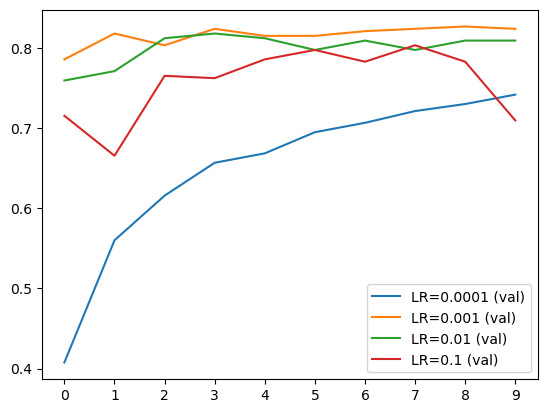

In [35]:


for lr, history in scores.items():
    plt.plot(history["val_accuracy"], label=f"LR={lr} (val)")
    #plt.plot(history["accuracy"], label=f"LR={lr} (train)")

plt.xticks(np.arange(10))
plt.legend()


## **8.7 - Checkpointing**
- Saving the best model only
- Training a model with callbacks

In [37]:
checkpoint = ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [38]:
learning_rate = 0.001
model = make_model(learning_rate)

history = model.fit(
    train_ds
    , epochs=10
    , validation_data=val_ds
    , callbacks=[checkpoint]
)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4595 - loss: 1.5863

48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 328ms/step - accuracy: 0.5919 - loss: 1.2172 - val_accuracy: 0.7390 - val_loss: 0.7806
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7461 - loss: 0.7237

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.7598 - loss: 0.7019 - val_accuracy: 0.7830 - val_loss: 0.6723
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7945 - loss: 0.6051

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.8096 - loss: 0.5728 - val_accuracy: 0.7918 - val_loss: 0.6150
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8414 - loss: 0.4974

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.8354 - loss: 0.5004 - val_accuracy: 0.8065 - val_loss: 0.6017
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.8611 - loss: 0.4451 - val_accuracy: 0.7977 - val_loss: 0.5744
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8769 - loss: 0.3994

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.8748 - loss: 0.4042 - val_accuracy: 0.8211 - val_loss: 0.5510
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8923 - loss: 0.3577

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - accuracy: 0.8905 - loss: 0.3634 - val_accuracy: 0.8299 - val_loss: 0.5425
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.9107 - loss: 0.3312 - val_accuracy: 0.8123 - val_loss: 0.5402
Epoch 9/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.9254 - loss: 0.2986 - val_accuracy: 0.8240 - val_loss: 0.5350
Epoch 10/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.9280 - loss: 0.2799 - val_accuracy: 0.8240 - val_loss: 0.5319


## **8.8 - Adding more Layers**
- Inner dense layers and outer dense layers


In [39]:
def make_model(learning_rate=0.01, size_inner=100):
    # Now let's train the model

    base_model = Xception(
        weights="imagenet"
        , include_top=False
        , input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    # Create a new "top", or Dense Layers
    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner)(vectors)

    outputs = keras.layers.Dense(10)(inner)
    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(
        optimizer=optimizer
        , loss=loss
        , metrics=["accuracy"]
    )

    return model

In [40]:
learning_rate = 0.001

sizes = [10, 100, 1000]

scores = {}

for size in tqdm(sizes):

    model = make_model(learning_rate=learning_rate, size_inner=size)

    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 326ms/step - accuracy: 0.5473 - loss: 1.3868 - val_accuracy: 0.7361 - val_loss: 0.8719
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.7357 - loss: 0.7965 - val_accuracy: 0.7683 - val_loss: 0.7035
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.7862 - loss: 0.6405 - val_accuracy: 0.7859 - val_loss: 0.6577
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.8204 - loss: 0.5440 - val_accuracy: 0.7977 - val_loss: 0.6259
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.8445 - loss: 0.4751 - val_accuracy: 0.8211 - val_loss: 0.5838
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.8739 - loss: 0.4137 - val_accuracy: 0.8035 - val_loss: 0.5711
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.8859 - loss: 0.3712 - val_accuracy: 0.8094 - val_loss: 0.5638
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.9019 - loss: 0.3325 - val_accuracy: 0

 33%|███▎      | 1/3 [01:33<03:06, 93.32s/it]



Epoch 1/10


2025-12-09 07:03:26.128238: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-09 07:03:27.029843: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4230', 64 bytes spill stores, 64 bytes spill loads



...

2025-12-09 07:05:11.894260: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3793', 800 bytes spill stores, 672 bytes spill loads

2025-12-09 07:05:11.899110: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4230', 104 bytes spill stores, 104 bytes spill loads



48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.5068 - loss: 2.6445

2025-12-09 07:05:20.154164: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1090', 4 bytes spill stores, 4 bytes spill loads

2025-12-09 07:05:20.231887: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1086', 56 bytes spill stores, 56 bytes spill loads



48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 359ms/step - accuracy: 0.6314 - loss: 1.7502 - val_accuracy: 0.7742 - val_loss: 0.7586
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.8243 - loss: 0.5541 - val_accuracy: 0.7801 - val_loss: 0.7500
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.8814 - loss: 0.3311 - val_accuracy: 0.8094 - val_loss: 0.6665
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.9016 - loss: 0.2882 - val_accuracy: 0.8240 - val_loss: 0.6734
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.9381 - loss: 0.1747 - val_accuracy: 0.8270 - val_loss: 0.6569
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.9684 - loss: 0.1067 - val_accuracy: 0.8299 - val_loss: 0.7225
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.9778 - loss: 0.0832 - val_accuracy: 0.8123 - val_loss: 0.6830
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.9905 - loss: 0.0532 - val_accuracy: 0.8328 - val

100%|██████████| 3/3 [04:45<00:00, 95.14s/it]

([<matplotlib.axis.YTick at 0x7f7d941c8190>,
 [Text(0, 0.78, '0.78'),
  Text(0, 0.8, '0.80'),
  Text(0, 0.82, '0.82'),
  Text(0, 0.84, '0.84')])

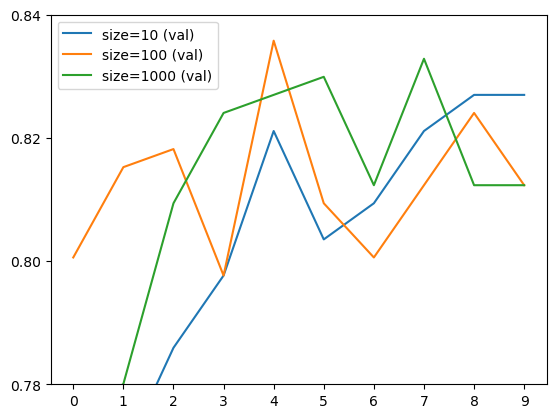

In [44]:

for size, history in scores.items():
    plt.plot(history["val_accuracy"], label=f"size={size} (val)")
    #plt.plot(history["accuracy"], label=f"LR={lr} (train)")

plt.xticks(np.arange(10))
plt.legend()
plt.ylim(0.78, 0.84)
plt.yticks([0.78, 0.8, 0.82, 0.84])

## **8.9 - Regularization and Dropout**
- Imagine an image of a t-shirt with a logo on it. Neural network will scan the logo each time during the epoch. 
- The logo will be added to the NN's idea of a t-shirt. 
- NN may see the logo on other items of clothing, i.e a beanie, and classify it as a t-shirt.

- Through each epoch, hide a different part of the image. This will mean the model sees a slightly different part of the image each iteration

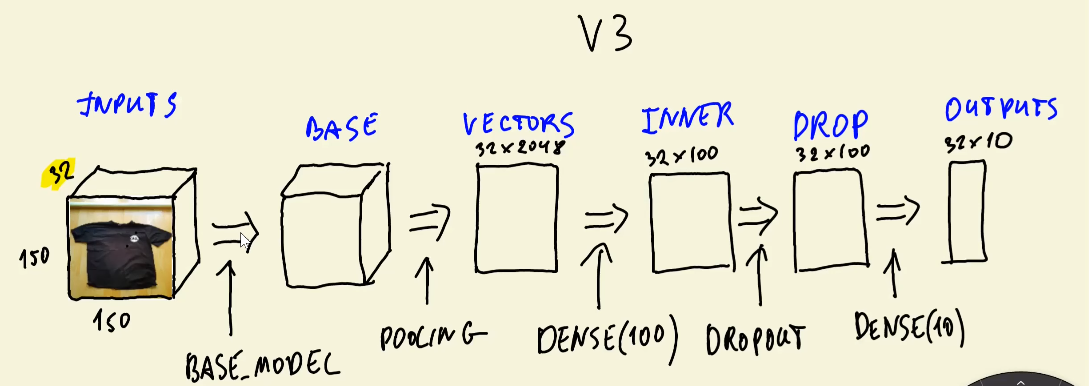

Adding dropout to the **INNER DENSE LAYER**

In [45]:
def make_model(learning_rate=0.01, size_inner=100, droprate=0.5):
    # Now let's train the model

    base_model = Xception(
        weights="imagenet"
        , include_top=False
        , input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    # Create a new "top", or Dense Layers
    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner)(vectors)

    # droprate refers to the percentage of neurons to drop
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)
    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(
        optimizer=optimizer
        , loss=loss
        , metrics=["accuracy"]
    )

    return model

In [46]:
learning_rate = 0.001

size = 100

droprates = [0.0, 0.2, 0.5, 0.8]

scores = {}

for droprate in tqdm(droprates):

    model = make_model(learning_rate=learning_rate, size_inner=size, droprate=droprate)

    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 341ms/step - accuracy: 0.6692 - loss: 1.0245 - val_accuracy: 0.7654 - val_loss: 0.6950
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.8279 - loss: 0.5011 - val_accuracy: 0.8035 - val_loss: 0.5793
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.8699 - loss: 0.3805 - val_accuracy: 0.7830 - val_loss: 0.6676
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.9051 - loss: 0.2867 - val_accuracy: 0.8094 - val_loss: 0.5665
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.9270 - loss: 0.2297 - val_accuracy: 0.8065 - val_loss: 0.6123
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.9449 - loss: 0.1847 - val_accuracy: 0.8152 - val_loss: 0.6054
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.9651 - loss: 0.1383 - val_accuracy: 0.8123 - val_loss: 0.6155
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.9707 - loss: 0.1174 - val_accuracy: 0

 25%|██▌       | 1/4 [04:15<12:47, 255.70s/it]



Epoch 1/30


2025-12-09 07:40:10.467143: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-09 07:40:11.391783: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4592', 100 bytes spill stores, 100 bytes spill loads



...

 50%|█████     | 2/4 [08:33<08:33, 256.75s/it]



Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 343ms/step - accuracy: 0.5952 - loss: 1.3369 - val_accuracy: 0.7713 - val_loss: 0.7361
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.7474 - loss: 0.7412 - val_accuracy: 0.7566 - val_loss: 0.7362
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.8005 - loss: 0.5625 - val_accuracy: 0.7859 - val_loss: 0.6492
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.8416 - loss: 0.4811 - val_accuracy: 0.7830 - val_loss: 0.6111
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.8628 - loss: 0.4081 - val_accuracy: 0.7977 - val_loss: 0.6081
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.8699 - loss: 0.3625 - val_accuracy: 0.8211 - val_loss: 0.5711
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.8973 - loss: 0.3060 - val_accuracy: 0.8065 - val_loss: 0.5606
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.9084 - loss: 0.2694 - val_accuracy:

 75%|███████▌  | 3/4 [12:49<04:16, 256.75s/it]



Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 342ms/step - accuracy: 0.4746 - loss: 2.0021 - val_accuracy: 0.7771 - val_loss: 0.7329
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.6375 - loss: 1.2570 - val_accuracy: 0.7830 - val_loss: 0.6769
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.6874 - loss: 1.0496 - val_accuracy: 0.7595 - val_loss: 0.7683
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.7060 - loss: 0.9721 - val_accuracy: 0.8065 - val_loss: 0.6239
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.7386 - loss: 0.8156 - val_accuracy: 0.8123 - val_loss: 0.5875
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.7595 - loss: 0.7389 - val_accuracy: 0.8211 - val_loss: 0.5437
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.7647 - loss: 0.7013 - val_accuracy: 0.8182 - val_loss: 0.5494
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.7790 - loss: 0.6775 - val_accuracy:

100%|██████████| 4/4 [17:05<00:00, 256.30s/it]

(0.78, 0.84)

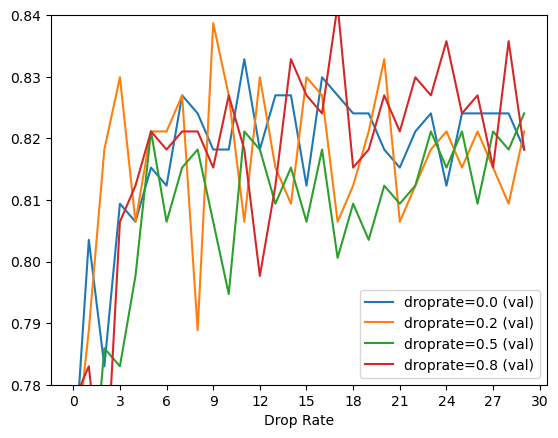

In [54]:

for droprate, history in scores.items():
    plt.plot(history["val_accuracy"], label=f"droprate={droprate} (val)")
    #plt.plot(history["accuracy"], label=f"LR={lr} (train)")

plt.xticks(np.arange(0, 31, 3))
plt.xlabel("Drop Rate")
plt.legend()
plt.ylim(0.78, 0.84)
#plt.yticks([0.78, 0.8, 0.82, 0.84])

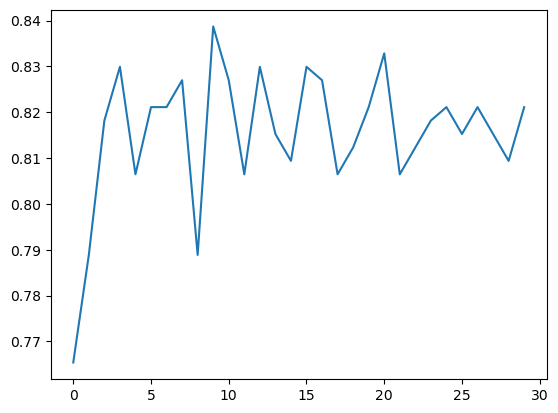

In [55]:
hist = scores[0.2]
plt.plot(hist["val_accuracy"], label=f"droprate={0.2} (val)")

## **8.10 - Data Augmentation**
- Image transformations to get more data:
    - Flip image horizontailly, vertically,both
    - Rotate image 
    - Shift image, horizontally, vertically
    - Shear (Stretch image on one side)
    - Shrink and Expand (zooming in and out)

- Choosing Augmentations:
    - Requires some judgement
    - Look at dataset and see what kind of variations there are. I.e are objects in the images always centered? 
    - Tune it as a hyperparameter. Try with different augmentations, compare validation scores
    

In [56]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    vertical_flip=True
)

train_dir = "clothing-dataset-small/train"
train_ds = train_gen.flow_from_directory(
    train_dir
    , target_size=(150, 150)
    , batch_size=64
)   

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_dir = "clothing-dataset-small/validation"
val_ds = val_gen.flow_from_directory(
    val_dir
    , target_size=(150, 150)
    , batch_size=64
    , shuffle=False
)       

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [57]:
learning_rate = 0.001

size = 100

droprate = 0.2

scores = {}


model = make_model(
    learning_rate=learning_rate, 
    size_inner=size, 
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds)
scores[droprate] = history.history



Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 504ms/step - accuracy: 0.5668 - loss: 1.4082 - val_accuracy: 0.7331 - val_loss: 0.7722
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 328ms/step - accuracy: 0.7135 - loss: 0.8759 - val_accuracy: 0.7507 - val_loss: 0.7257
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 327ms/step - accuracy: 0.7334 - loss: 0.7771 - val_accuracy: 0.7830 - val_loss: 0.6730
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 324ms/step - accuracy: 0.7846 - loss: 0.6495 - val_accuracy: 0.7918 - val_loss: 0.7028
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 333ms/step - accuracy: 0.7898 - loss: 0.6073 - val_accuracy: 0.7947 - val_loss: 0.6444
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 327ms/step - accuracy: 0.7976 - loss: 0.5837 - val_accuracy: 0.7859 - val_loss: 0.6673
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 328ms/step - accuracy: 0.8028 - loss: 0.5871 - val_accuracy: 0.7830 - val_loss: 0.6302
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 321ms/step - accuracy: 0.8126 - loss: 0.5246 - val_accu

In [60]:
scores[0.2]["val_accuracy"]

[0.733137845993042,
 0.7507331371307373,
 0.7829912304878235,
 0.7917888760566711,
 0.7947214245796204,
 0.7859237790107727,
 0.7829912304878235,
 0.7976539731025696,
 0.7947214245796204,
 0.7800586223602295,
 0.7976539731025696,
 0.7888563275337219,
 0.7917888760566711,
 0.7947214245796204,
 0.7800586223602295,
 0.7947214245796204,
 0.8005865216255188,
 0.7976539731025696,
 0.7976539731025696,
 0.8328445553779602,
 0.7976539731025696,
 0.8093841671943665,
 0.7888563275337219,
 0.803519070148468,
 0.8123167157173157,
 0.8093841671943665,
 0.7947214245796204,
 0.7888563275337219,
 0.7976539731025696,
 0.8093841671943665,
 0.7947214245796204,
 0.7624633312225342,
 0.7829912304878235,
 0.7800586223602295,
 0.803519070148468,
 0.7829912304878235,
 0.7653958797454834,
 0.7859237790107727,
 0.7653958797454834,
 0.7888563275337219,
 0.7947214245796204,
 0.7859237790107727,
 0.8005865216255188,
 0.7917888760566711,
 0.7859237790107727,
 0.8005865216255188,
 0.7771260738372803,
 0.7976539731025

Text(0, 0.5, 'Validation Accuracy')

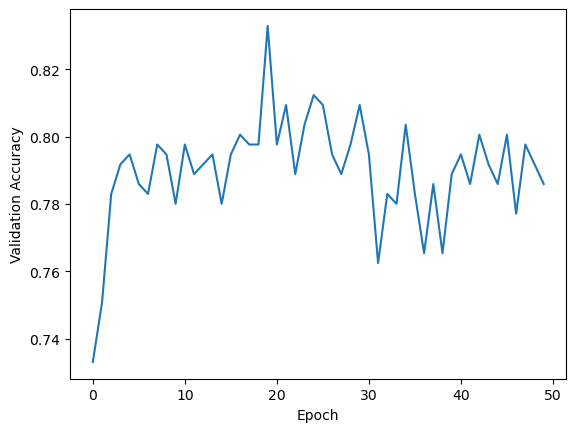

In [64]:
plt.plot(scores[0.2]["val_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

## **8.11 - Training a larger model**
- Train a 299x299 model

In [2]:
def make_model(learning_rate=0.01, size_inner=100, droprate=0.5, input_shape=(150, 150, 3)):
    # Now let's train the model

    base_model = Xception(
        weights="imagenet"
        , include_top=False
        , input_shape=input_shape
    )

    base_model.trainable = False

    # Create a new "top", or Dense Layers
    inputs = keras.Input(shape=input_shape)
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner)(vectors)

    # droprate refers to the percentage of neurons to drop
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)
    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(
        optimizer=optimizer
        , loss=loss
        , metrics=["accuracy"]
    )

    return model

In [9]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
)

train_dir = "clothing-dataset-small/train"
train_ds = train_gen.flow_from_directory(
    train_dir
    , target_size=(299, 299)
    , batch_size=64
)   

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_dir = "clothing-dataset-small/validation"
val_ds = val_gen.flow_from_directory(
    val_dir
    , target_size=(299, 299)
    , batch_size=64
    , shuffle=False
)       




Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [10]:
checkpoint = ModelCheckpoint(
    'xception_v4_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [12]:
learning_rate = 0.001
size = 100
droprate = 0.2
input_shape = (299, 299, 3)

model = make_model(
    learning_rate=learning_rate, 
    size_inner=size, 
    droprate=droprate, 
    input_shape=input_shape
)

history = model.fit(
    train_ds
    , epochs=50
    , validation_data=val_ds
    , callbacks=[checkpoint]
)
scores[droprate] = history.history


Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.6050 - loss: 1.1733

48/48 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.7301 - loss: 0.8181 - val_accuracy: 0.8035 - val_loss: 0.5616
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8382 - loss: 0.4526

48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 852ms/step - accuracy: 0.8462 - loss: 0.4405 - val_accuracy: 0.8651 - val_loss: 0.4104
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 841ms/step - accuracy: 0.8722 - loss: 0.3697 - val_accuracy: 0.8563 - val_loss: 0.4159
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.8906 - loss: 0.3247

48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 857ms/step - accuracy: 0.8957 - loss: 0.3117 - val_accuracy: 0.8827 - val_loss: 0.3715
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 848ms/step - accuracy: 0.8967 - loss: 0.2957 - val_accuracy: 0.8739 - val_loss: 0.3699
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 831ms/step - accuracy: 0.9097 - loss: 0.2573 - val_accuracy: 0.8739 - val_loss: 0.3654
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 830ms/step - accuracy: 0.9231 - loss: 0.2353 - val_accuracy: 0.8739 - val_loss: 0.3853
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 827ms/step - accuracy: 0.9237 - loss: 0.2266 - val_accuracy: 0.8827 - val_loss: 0.3797
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 833ms/step - accuracy: 0.9241 - loss: 0.2171 - val_accuracy: 0.8739 - val_loss: 0.3754
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.9294 - loss: 0.1905

48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 831ms/step - accuracy: 0.9289 - loss: 0.1958 - val_accuracy: 0.8856 - val_loss: 0.3673
Epoch 11/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 831ms/step - accuracy: 0.9371 - loss: 0.1791 - val_accuracy: 0.8739 - val_loss: 0.4003
Epoch 12/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 831ms/step - accuracy: 0.9465 - loss: 0.1587 - val_accuracy: 0.8710 - val_loss: 0.4097
Epoch 13/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 831ms/step - accuracy: 0.9492 - loss: 0.1596 - val_accuracy: 0.8798 - val_loss: 0.3899
Epoch 14/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 835ms/step - accuracy: 0.9459 - loss: 0.1582 - val_accuracy: 0.8622 - val_loss: 0.4361
Epoch 15/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 828ms/step - accuracy: 0.9465 - loss: 0.1518 - val_accuracy: 0.8856 - val_loss: 0.4067
Epoch 16/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 836ms/step - accuracy: 0.9514 - loss: 0.1413 - val_accuracy: 0.8798 - val_loss: 0.4008
Epoch 17/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 831ms/step - accuracy: 0.9537 - loss: 0.1397 - val_accuracy

KeyboardInterrupt: 

## **8.12 - Using the Model**
- Loading the model
- Evaluating the model
- Getting Predictions

In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import preprocess_input

from tensorflow.keras.preprocessing.image import load_img
import numpy as np


In [17]:
keras.models.load_model('xception_v4_10_0.886.h5')

<Functional name=functional_3, built=True>

In [ ]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_dir = "clothing-dataset-small/test"
test_ds = test_gen.flow_from_directory(
    test_dir
    , target_size = (299, 299)
    , batch_size = 32
    , shuffle=False

)

Found 372 images belonging to 10 classes.


In [20]:
model.evaluate(test_ds)

2025-12-10 07:36:41.465040: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-10 07:36:41.628484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-10 07:36:43.293691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-10 07:36:43.440460: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-10 07:36:44.606996: E external/local_xla/xla/stream_

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8213 - loss: 0.5646

2025-12-10 07:36:57.336709: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-10 07:36:57.481777: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-10 07:36:58.757729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-10 07:36:58.893564: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-10 07:36:59.724324: E external/local_xla/xla/stream_

12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8871 - loss: 0.3581 


[0.35808104276657104, 0.8870967626571655]

In [21]:
path = "clothing-dataset-small/test/pants/c8d21106-bbdb-4e8d-83e4-bf3d14e54c16.jpg"

In [27]:
img = load_img(path, target_size=(299, 299))

In [32]:
x = np.array(img)
X = np.array([x])
X = preprocess_input(X)
X

array([[[[ 0.09803927,  0.06666672, -0.01960784],
         [ 0.10588241,  0.07450986, -0.01176471],
         [ 0.12156868,  0.09019613,  0.00392163],
         ...,
         [ 0.05098045,  0.0196079 , -0.0745098 ],
         [ 0.05882359,  0.02745104, -0.06666666],
         [-0.04313725, -0.0745098 , -0.16862744]],

        [[ 0.12156868,  0.09019613,  0.00392163],
         [ 0.13725495,  0.10588241,  0.0196079 ],
         [ 0.14509809,  0.11372554,  0.02745104],
         ...,
         [ 0.05098045,  0.0196079 , -0.0745098 ],
         [ 0.05882359,  0.02745104, -0.06666666],
         [-0.00392157, -0.03529412, -0.12941176]],

        [[ 0.13725495,  0.10588241,  0.0196079 ],
         [ 0.15294123,  0.12156868,  0.03529418],
         [ 0.16078436,  0.12941182,  0.04313731],
         ...,
         [ 0.04313731,  0.01176476, -0.08235294],
         [ 0.05882359,  0.02745104, -0.06666666],
         [ 0.02745104, -0.00392157, -0.09803921]],

        ...,

        [[ 0.20000005,  0.18431377,  0

In [35]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [39]:
classes = list(train_ds.class_indices.keys())
classes

['dress',
 'hat',
 'longsleeve',
 'outwear',
 'pants',
 'shirt',
 'shoes',
 'shorts',
 'skirt',
 't-shirt']

In [43]:
predictions = dict(zip(classes, pred[0]))
predictions

{'dress': np.float32(-2.5017366),
 'hat': np.float32(-2.8770382),
 'longsleeve': np.float32(-1.1454505),
 'outwear': np.float32(-1.5268396),
 'pants': np.float32(14.468993),
 'shirt': np.float32(-1.265191),
 'shoes': np.float32(-1.6865318),
 'shorts': np.float32(8.231068),
 'skirt': np.float32(-4.7154326),
 't-shirt': np.float32(-0.15245955)}